In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

from scipy.optimize import curve_fit, minimize

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
# perexp = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/sv1_perexp_lrg.fits'))
perexp = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_perexp_lrg.fits'))

# Remove FIBERSTATUS!=0 fibers
mask = perexp['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
perexp = perexp[mask]

# Remove "no data" fibers
mask = perexp['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
perexp = perexp[mask]

# Apply LRG mask
mask = perexp['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
perexp = perexp[mask]

# Remove QSO targets
mask = perexp['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
perexp = perexp[mask]

FIBERSTATUS 464751 107007 0.18715435551404616
No data 464751 0 0.0
LRG mask 417693 47058 0.10125422000167832
Remove QSO targets 403772 13921 0.03332830571735701


In [4]:
# cat_1x = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/sv1_1x_depth_lrg.fits'))
cat_1x = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_1x_depth_lrg.fits'))

# Remove FIBERSTATUS!=0 fibers
mask = cat_1x['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Remove "no data" fibers
mask = cat_1x['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Apply LRG mask
mask = cat_1x['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Remove QSO targets
mask = cat_1x['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

FIBERSTATUS 27110 4943 0.15421333416528873
No data 27110 0 0.0
LRG mask 25008 2102 0.07753596458871265
Remove QSO targets 24493 515 0.020593410108765194


In [5]:
# deep = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/sv1_cumulative_lrg.fits'))
deep = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_cumulative_lrg.fits'))

# Remove FIBERSTATUS!=0 fibers
mask = deep['COADD_FIBERSTATUS']==0
print('COADD_FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

mask = deep['ZWARN']==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Apply LRG mask
mask = deep['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove QSO targets
mask = deep['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

COADD_FIBERSTATUS 46319 8916 0.16141938987960533
No data 45437 882 0.01904186187093849
LRG mask 41340 4097 0.09016880515879129
Remove QSO targets 39668 1672 0.040445089501693274


In [6]:
# main = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/main_cumulative_lrg.fits'))
main = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/main_cumulative_lrg.fits'))

# Remove FIBERSTATUS!=0 fibers
mask = main['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Remove "no data" fibers
mask = main['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Apply LRG mask
mask = main['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Remove QSO targets
mask = main['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

FIBERSTATUS 338266 7165 0.020742203218587794
No data 338265 1 2.9562533627382e-06
LRG mask 304337 33928 0.1003000606033731
Remove QSO targets 299639 4698 0.015436834824553046


In [7]:
# sv3 = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/sv3_cumulative_lrg.fits'))
sv3 = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv3_cumulative_lrg.fits'))

# Remove FIBERSTATUS!=0 fibers
mask = sv3['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
sv3 = sv3[mask]

# Remove "no data" fibers
mask = sv3['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
sv3 = sv3[mask]

# Apply LRG mask
mask = sv3['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
sv3 = sv3[mask]

# Remove QSO targets
mask = sv3['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
sv3 = sv3[mask]

FIBERSTATUS 164618 18004 0.09858615062807329
No data 164614 4 2.4298679366776417e-05
LRG mask 150726 13888 0.08436706476970367
Remove QSO targets 150726 0 0.0


In [247]:
cat = vstack([perexp, cat_1x, main, deep, sv3], join_type='inner')
print(len(cat))

cat['EFFTIME_ELG'] = 8.60 * cat['TSNR2_ELG']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']
cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']

918298


In [8]:
cat = main.copy()

cat['EFFTIME_ELG'] = 8.60 * cat['TSNR2_ELG']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']
cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']

In [9]:
mask = cat['EFFTIME_LRG']>500
mask &= cat['EFFTIME_LRG']<2000
cat = cat[mask]
print(len(cat))

mask = cat['zfibermag']>19.
mask &= cat['zfibermag']<22.
cat = cat[mask]
print(len(cat))

295855
294763


In [10]:
# mask = cat['zfibermag']>19.
# mask &= cat['zfibermag']<21.4
# cat = cat[mask]
# print(len(cat))

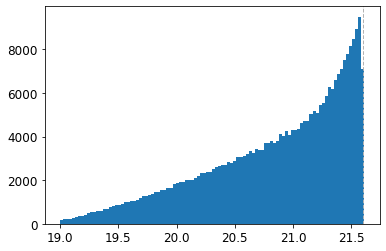

In [11]:
plt.hist(cat['zfibermag'], 100)
plt.axvline(21.6, ls='--', color='0.7', lw=1)
plt.show()

In [12]:
# Custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*cat['Z']))
cat['q'] = ((cat['DELTACHI2']>d) & (cat['DELTACHI2']>10)) | (cat['DELTACHI2']>30)
cat['q'] &= cat['Z']<1.4
cat['q'] &= cat['ZWARN']<1.4
cat['qf'] = np.array(cat['q'], dtype=float)

In [13]:
print(np.sum((~cat['q'])), np.sum((~cat['q']))/len((~cat['q'])))
mask = (cat['EFFTIME_LRG']>800) & (cat['EFFTIME_LRG']<1200)
print(np.sum((~cat['q']) & mask), np.sum((~cat['q']) & mask)/np.sum(mask))

3510 0.011907871747810952
2981 0.011475977825685248


In [14]:
def lrg_sn(flux, efftime):
    return flux * np.sqrt(efftime)

In [17]:
cat['FIBERFLUX_Z_EC'] = cat['FIBERFLUX_Z']*10**(0.4*1.211*cat['EBV'])
cat['FIBERFLUX_R_EC'] = cat['FIBERFLUX_R']*10**(0.4*1.211*cat['EBV'])
# cat['sn'] = lrg_sn(cat['FIBERFLUX_Z_EC'], cat['EFFTIME_LRG'])

KeyError: 'FIBERFLUX_R'

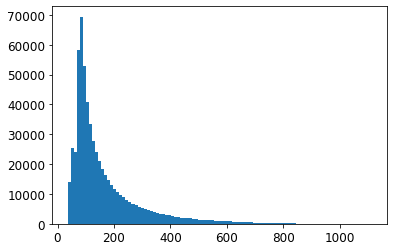

In [255]:
plt.hist(cat['sn'], 100);

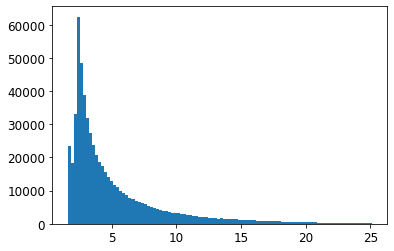

In [256]:
plt.hist(cat['FIBERFLUX_Z_EC'], 100);

In [263]:
def cost(q_predict):
    return np.sum((cat['qf']-q_predict)**2)

def wrapper(x):
    q_predict = success_rate(cat['FIBERFLUX_Z_EC'], cat['EFFTIME_LRG'], *x)
    return cost(q_predict)

# def success_rate(flux, efftime, a, b):
#     sn = flux * np.sqrt(efftime)
#     return np.clip(1-np.exp(-(sn+a)/b), 0, 1)
# res = minimize(wrapper, [0, 10.], bounds=((-200, 200), (0, 100)),
#                method='Powell', tol=1e-6)

# # Include minimal failure rate
# def success_rate(flux, efftime, a, b, c):
#     sn = flux * np.sqrt(efftime)
#     return np.clip(1-np.exp(-(sn+a)/b)-c, 0, 1)
# res = minimize(wrapper, [0, 10., 0.001], bounds=((-200, 200), (0, 100), (0, 0.01)),
#                method='Powell', tol=1e-6)

# # Include sky contribution
# def success_rate(flux, efftime, a, b, c):
#     sn = flux / np.sqrt(flux + c) * np.sqrt(efftime)
#     return np.clip(1-np.exp(-(sn+a)/b), 0, 1)
# res = minimize(wrapper, [-1.16346025e-01, 2.3,  10],
#                method='Powell', tol=1e-6)

# Include a fixed sky contribution
sky_mag = 18.46
sky_flux = np.pi*(1.46/2)**2 * 10**(-0.4*(sky_mag-22.5))
def success_rate(flux, efftime, a, b):
    sn = flux / np.sqrt(flux + sky_flux) * np.sqrt(efftime)
    return np.clip(1-np.exp(-(sn+a)/b), 0, 1)
res = minimize(wrapper, [-1.16346025e-01, 2.3],
               method='Powell', tol=1e-6)

print(res)
x = res.x
print()
print(wrapper(x))

   direc: array([[-7.45334247e-01, -3.92543235e-01],
       [-4.11403938e-04, -6.30969843e-04]])
     fun: 15416.296178764629
 message: 'Optimization terminated successfully.'
    nfev: 268
     nit: 5
  status: 0
 success: True
       x: array([-3.35608095,  1.677519  ])

15416.296178764629


In [271]:
x = [-1.29423961,  2.30330222]

In [272]:
# xx = np.linspace(10, 100, 200)
# plt.plot(xx, success_rate(xx, *x))
# plt.grid(alpha=0.5)
# plt.show()

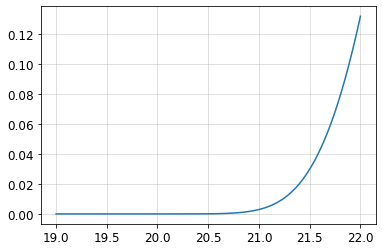

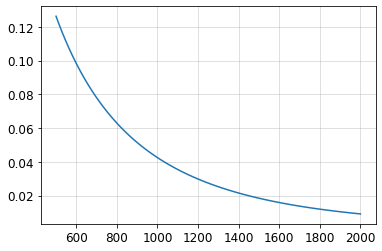

Failure rate at zfiber=21.6:
0.04245896452489384


In [273]:
zfiber = np.linspace(19, 22, 100)
flux = 10**(-0.4*(zfiber-22.5))
efftime = np.full(len(zfiber), 1000.)
sn = lrg_sn(flux, efftime)
plt.plot(zfiber, 1-success_rate(flux, efftime, *x))
plt.grid(alpha=0.5)
plt.show()

efftime = np.linspace(500, 2000, 100)
zfiber = np.full(len(efftime), 21.6)
flux = 10**(-0.4*(zfiber-22.5))
sn = lrg_sn(flux, efftime)
plt.plot(efftime, 1-success_rate(flux, efftime, *x))
plt.grid(alpha=0.5)
plt.show()

zfiber = 21.6
flux = 10**(-0.4*(zfiber-22.5))
efftime = 1000.
sn = lrg_sn(flux, efftime)

print('Failure rate at zfiber=21.6:')
print(1-success_rate(flux, efftime, *x))

<ipython-input-274-f11aa4e9d78e>:7: RuntimeWarning: invalid value encountered in true_divide
  success_2d = count_2d_good/count_2d_all


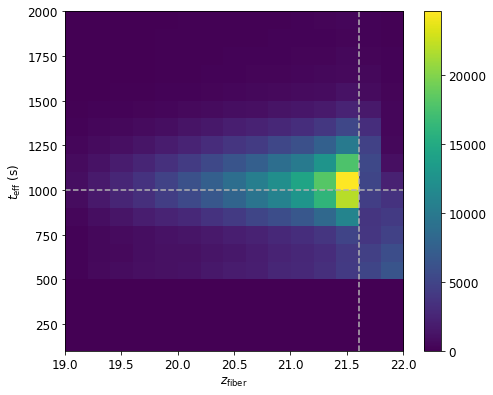

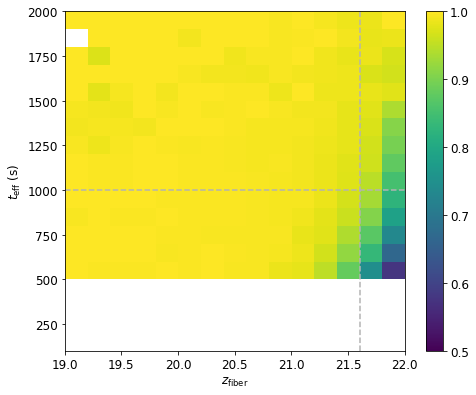

In [274]:
zfiber_bin_edges = np.linspace(18.0, 22.0, 21)
efftime_bin_edges = np.linspace(100, 2000, 20)

count_2d_all = np.histogram2d(cat['zfibermag'], cat['EFFTIME_LRG'], bins=[zfiber_bin_edges, efftime_bin_edges])[0]
mask = cat['q'].copy()
count_2d_good = np.histogram2d(cat['zfibermag'][mask], cat['EFFTIME_LRG'][mask], bins=[zfiber_bin_edges, efftime_bin_edges])[0]
success_2d = count_2d_good/count_2d_all

success_2d[count_2d_all<=20] = np.nan

fig, ax = plt.subplots(figsize=(7, 5.6))
cax = ax.imshow(count_2d_all.T, origin='lower', aspect='auto',
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$')
ax.set_ylabel('$t_\mathrm{eff}$ (s)')
ax.set_xlim(xmin=19)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_failure_rate_in_2d.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(7, 5.6))
cax = ax.imshow(success_2d.T, origin='lower', aspect='auto', vmin=0.5, vmax=1.,
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$')
ax.set_ylabel('$t_\mathrm{eff}$ (s)')
ax.set_xlim(xmin=19)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_failure_rate_in_2d.pdf')
plt.show()

<ipython-input-275-39c92b6c3747>:4: RuntimeWarning: invalid value encountered in true_divide
  success_2d_predict = count_2d_good_predict/count_2d_all


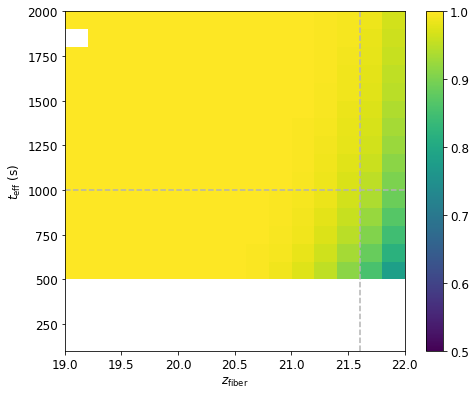

In [275]:
cat['success_prob'] = success_rate(cat['FIBERFLUX_Z_EC'], cat['EFFTIME_LRG'], *x)
count_2d_good_predict = np.histogram2d(cat['zfibermag'], cat['EFFTIME_LRG'], bins=[zfiber_bin_edges, efftime_bin_edges], weights=cat['success_prob'])[0]

success_2d_predict = count_2d_good_predict/count_2d_all

success_2d_predict[count_2d_all<=20] = np.nan

fig, ax = plt.subplots(figsize=(7, 5.6))
cax = ax.imshow(success_2d_predict.T, origin='lower', aspect='auto', vmin=0.5, vmax=1.,
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$')
ax.set_ylabel('$t_\mathrm{eff}$ (s)')
ax.set_xlim(xmin=19)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_failure_rate_in_2d.pdf')
plt.show()

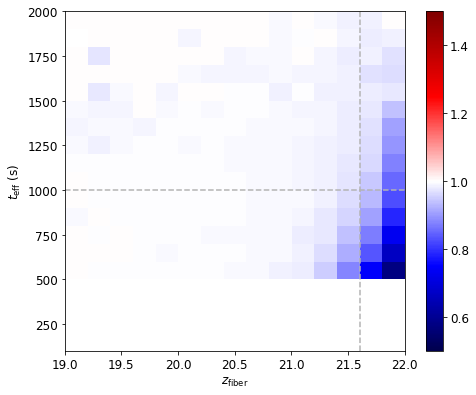

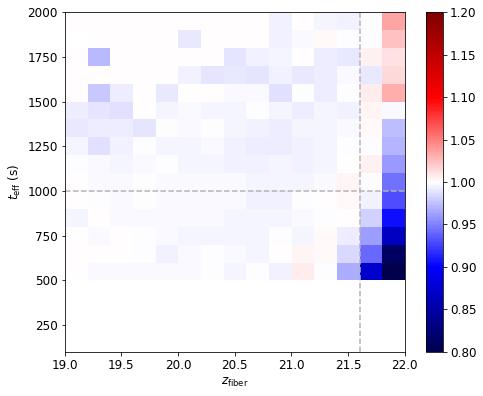

In [276]:
fig, ax = plt.subplots(figsize=(7, 5.6))
cax = ax.imshow((success_2d).T, origin='lower', aspect='auto', vmin=0.5, vmax=1.5, cmap='seismic',
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$')
ax.set_ylabel('$t_\mathrm{eff}$ (s)')
ax.set_xlim(xmin=19)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_failure_rate_in_2d.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(7, 5.6))
cax = ax.imshow((success_2d/success_2d_predict).T, origin='lower', aspect='auto', vmin=0.8, vmax=1.2, cmap='seismic',
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$')
ax.set_ylabel('$t_\mathrm{eff}$ (s)')
ax.set_xlim(xmin=19)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/main_failure_rate_in_2d.pdf')
plt.show()

In [146]:
perexp

TARGETID,Z,ZERR,ZWARN,CHI2,SPECTYPE,DELTACHI2,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,TARGET_RA,TARGET_DEC,MORPHTYPE,EBV,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FIBERFLUX_Z,MASKBITS,PARALLAX,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,DESI_TARGET,BGS_TARGET,TILEID,NIGHT,EXPID,EXPTIME,FIBERSTATUS,DELTA_X,DELTA_Y,TSNR2_ELG,TSNR2_BGS,TSNR2_QSO,TSNR2_LRG,fn,EFFTIME_DARK_GFA,lrg_mask,main_lrg
int64,float64,float64,int64,float64,str6,float64,int16,int32,int64,int32,float64,float64,str4,float32,float32,float32,float32,float32,float32,float32,int16,float32,str1,int64,int64,int64,int64,int32,int32,int32,float64,int32,float64,float64,float32,float32,float32,float32,str65,float64,int16,bool
39627169034405158,3.789348966408134e-05,4.999431893348628e-05,4,8051.379848411278,STAR,1.0713535640679765,1,442,1442,515,157.50687199162041,-26.41260068999448,PSF,0.07591335,0.037983153,0.31110612,3.0313737,9.149264,6.5843215,2.3608506,0,0.0,S,100663393,0,0,0,80702,20210306,79560,1073.306,0,0.006,0.005,55.89896,3262.5012,13.275883,38.404144,fuji/tiles/perexp/80702/00079560/redrock-1-80702-exp00079560.fits,0.0,0,False
39627169034405158,-2.4111450015236182e-05,2.4915912493211713e-05,0,7719.390288061793,GALAXY,41.93727541774933,1,442,1442,515,157.50687199162041,-26.41260068999448,PSF,0.07591335,0.037983153,0.31110612,3.0313737,9.149264,6.5843215,2.3608506,0,0.0,S,100663393,0,0,0,80702,20210306,79561,1073.3181,0,-0.004,0.015,30.453743,1805.1809,7.0438194,20.79816,fuji/tiles/perexp/80702/00079561/redrock-1-80702-exp00079561.fits,0.0,0,False
39627169034405158,-1.1223620956400514e-06,2.2261315533222515e-05,0,7857.046009106592,GALAXY,20.360605621680406,1,442,1442,515,157.50687199162041,-26.41260068999448,PSF,0.07591335,0.037983153,0.31110612,3.0313737,9.149264,6.5843215,2.3608506,0,0.0,S,100663393,0,0,0,80702,20210319,81062,1200.0535,0,-0.001,0.005,29.232197,1653.7517,6.731215,18.779295,fuji/tiles/perexp/80702/00081062/redrock-1-80702-exp00081062.fits,0.0,0,False
39627169034405158,-8.66290774390966e-05,2.441948331922605e-05,0,7690.359866106807,GALAXY,51.4838891533027,1,442,1442,515,157.50687199162041,-26.41260068999448,PSF,0.07591335,0.037983153,0.31110612,3.0313737,9.149264,6.5843215,2.3608506,0,0.0,S,100663393,0,0,0,80702,20210306,79562,1073.2981,0,0.002,-0.004,59.80603,3468.0452,14.21991,41.0403,fuji/tiles/perexp/80702/00079562/redrock-1-80702-exp00079562.fits,0.0,0,False
39627169034405158,-5.4312793510801505e-05,4.3670687032592926e-05,0,7978.827644658118,STAR,79.43685725626437,1,442,1442,515,157.50687199162041,-26.41260068999448,PSF,0.07591335,0.037983153,0.31110612,3.0313737,9.149264,6.5843215,2.3608506,0,0.0,S,100663393,0,0,0,80702,20210318,80951,1200.0627,0,-0.004,0.008,58.561493,3386.513,13.792591,39.636513,fuji/tiles/perexp/80702/00080951/redrock-1-80702-exp00080951.fits,0.0,0,False
39627169034405158,-2.8036997804534436e-05,3.2821762426151275e-05,4,7550.883927846043,GALAXY,4.797830308140874,1,442,1442,515,157.50687199162041,-26.41260068999448,PSF,0.07591335,0.037983153,0.31110612,3.0313737,9.149264,6.5843215,2.3608506,0,0.0,S,100663393,0,0,0,80702,20210305,79442,978.1015,0,0.0,0.005,21.909023,1287.15,5.1448493,14.83474,fuji/tiles/perexp/80702/00079442/redrock-1-80702-exp00079442.fits,0.0,0,False
39627169034405158,-7.450255918427974e-05,3.367519352449014e-05,0,7741.720015983291,GALAXY,17.74852753876894,1,442,1442,515,157.50687199162041,-26.41260068999448,PSF,0.07591335,0.037983153,0.31110612,3.0313737,9.149264,6.5843215,2.3608506,0,0.0,S,100663393,0,0,0,80702,20210305,79444,978.1267,0,0.001,0.0,9.1208725,532.4795,2.1074085,6.0275064,fuji/tiles/perexp/80702/00079444/redrock-1-80702-exp00079444.fits,0.0,0,False
39627169034405158,1.6055086748069891,8.205995216801964e-05,4,7981.383729159832,GALAXY,6.7026738077402115,1,442,1442,515,157.50687199162041,-26.41260068999448,PSF,0.07591335,0.037983153,0.31110612,3.0313737,9.149264,6.5843215,2.3608506,0,0.0,S,100663393,0,0,0,80702,20210319,81063,1200.0645,0,0.001,0.002,49.201614,2857.4248,11.598534,32.879005,fuji/tiles/perex